# 第2章 现金流、复利与贴现

上一章，小林完成了第一份资产比较报告，却发现现金、债券、股票和基金都把今天投入的钱与未来收到的钱联系在一起。如果不同时间的金额不能直接比较，他还缺少一把共同的“时间标尺”。

> **贯穿任务**：小林将从10,000元奖学金出发，依次比较未来金额、复利频率、校园项目现金流和通胀购买力，最终建立一份大学四年现金流比较报告。

> **核心问题**：今天的100元为什么通常不等于一年后的100元？如何在不同时间的现金流之间进行可解释的比较？

- 金融线：时间价值、现值、终值、净现值、通胀与定期投入。
- 数学线：指数、对数、极限与方程求根。
- Python线：函数参数、数组广播、表格、数值求根和交互滑块。

**学习目标**
完成本章后，学生应能画现金流时间轴、区分增长与贴现、计算NPV，并说明利率不是脱离风险和期限的“常数”。

## AI学习状态

当前进度：第2章开始  
已掌握：简单收益率、函数和NumPy基础  
仍然薄弱：待填写  
下一步：每个公式先用一笔现金流手算。

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 2.1 不同时间的钱不能直接相加

小林想比较“今天保留奖学金”和“几年后用于学习支出”这两件事。他先拿100元建立一个可手算的小模型。

假设今天的100元可以按5%的年利率增长，那么一年后会变成105元：

$$100\times(1+5\%)=105$$

如果反过来问：“一年后的105元，相当于今天多少元？”就要把增长过程倒过来：

$$105\div(1+5\%)=100$$

### 先认识一个新词：贴现率

- 从今天的100元算到未来的105元，是向未来计算**增长**；
- 从未来的105元换算回今天的100元，是向今天计算**贴现**；
- 反向换算时使用的5%，就叫作**贴现率**。

这里的“贴现”是比较今天金额和未来金额时采用的一把比例尺。本章中的5%或8%都只是为了学习计算而设定的假设。

对同一笔未来金额，假设的贴现率越高，换算出的今天金额越小。直观地说：如果今天的钱本来可以增长得更快，那么为了得到同样的未来金额，今天需要准备的钱就更少。

用字母把同一个过程写短：$PV$表示今天的金额（现值），$FV$表示未来的金额（终值），$r$表示每年的比例，$n$表示年数。每年复利一次时：

$$FV=PV(1+r)^n,\qquad PV=\frac{FV}{(1+r)^n}$$

增长把今天推向未来；贴现把未来拉回今天。两者是同一关系的相反方向。
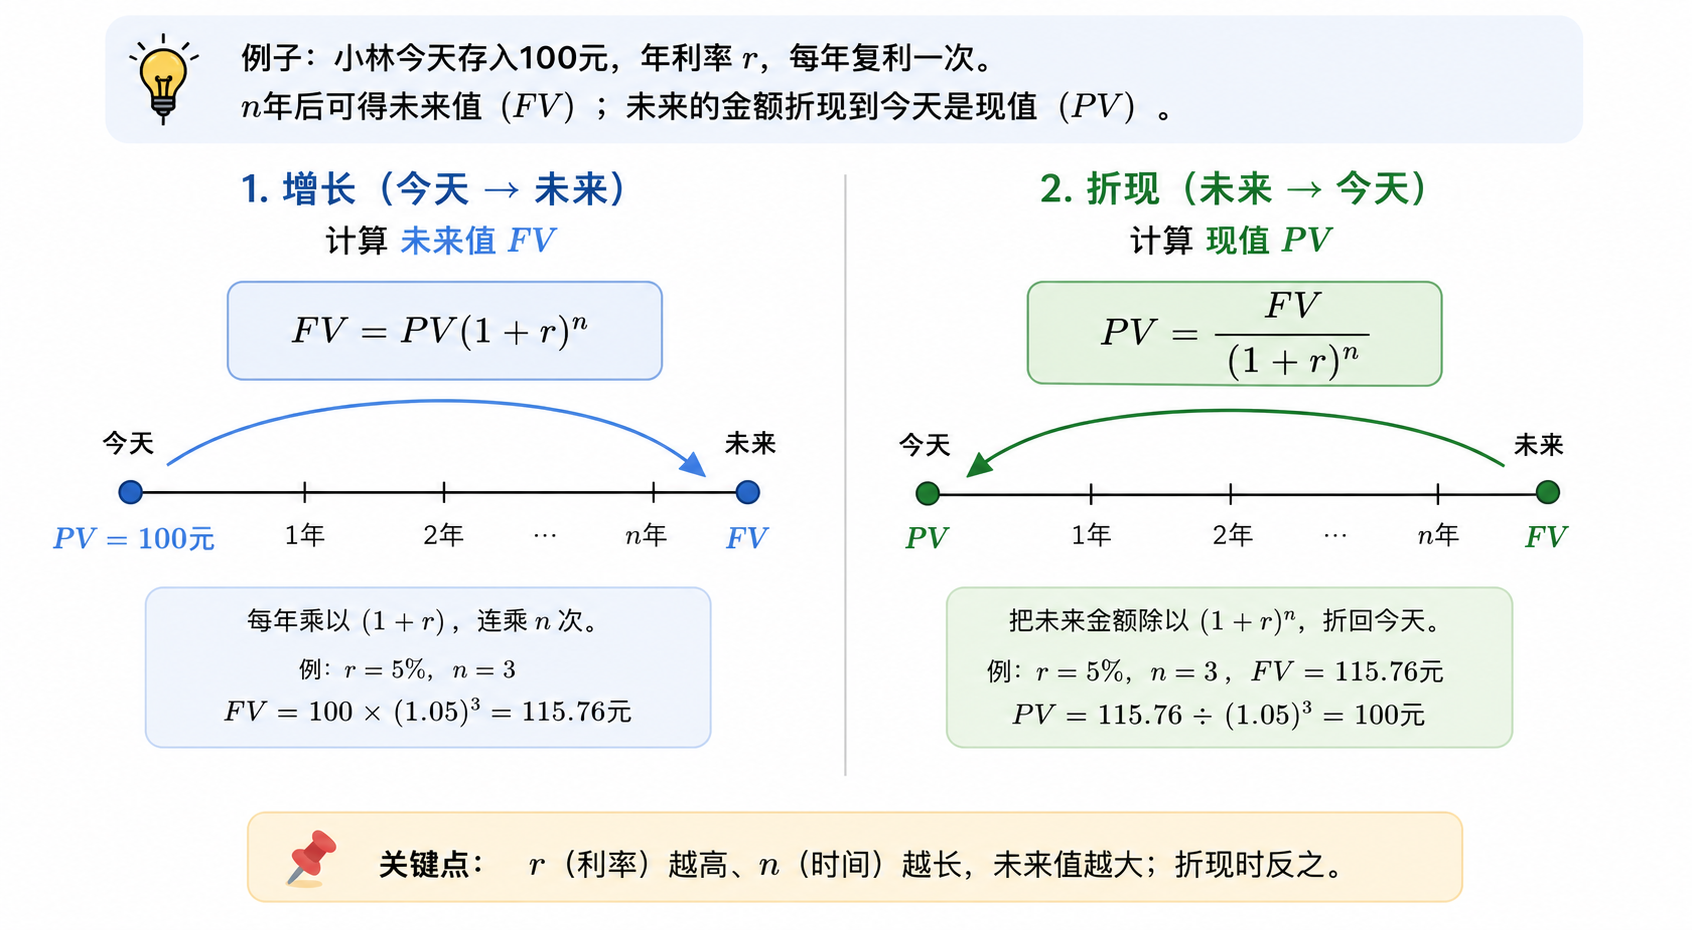

### 帮小林先预测

100元按5%年利率增长3年，终值应高于还是低于115元？再把这个终值按相同规则贴现3年，能否回到100元？如果贴现率提高，同一笔未来金额的现值应上升还是下降？

### 我的预测

<!-- 在这里填写；完成前AI不要代答 -->

In [9]:
present_value = 100
rate = 0.05
years = 3

future_value = present_value * (1 + rate) ** years
recovered_pv = future_value / (1 + rate) ** years
print({"终值": round(future_value, 2), "贴现回来的现值": round(recovered_pv, 2)})

{'终值': 115.76, '贴现回来的现值': 100.0}


**Python提示：用关键字参数减少歧义**

金融函数常有多个同为数值的参数。调用时写成`pv(amount=..., rate=..., years=...)`，比只写位置更不容易把期限和利率放反。

In [10]:
def fv(amount, rate, years, compounds_per_year=1):
    # 名义年利率rate，每年复利compounds_per_year次。
    periods = years * compounds_per_year
    return amount * (1 + rate / compounds_per_year) ** periods


def pv(amount, rate, years, compounds_per_year=1):
    return amount / (1 + rate / compounds_per_year) ** (years * compounds_per_year)


print(fv(amount=1_000, rate=0.06, years=2))
print(pv(amount=1_123.60, rate=0.06, years=2))

1123.6000000000001
999.9999999999998


## 2.2 不同的复利频率

小林看到两个方案都写着“名义年利率8%”，但一个按年计息，另一个更频繁地计息。他意识到只看年利率数字还不够，还必须检查复利频率。

名义年利率为 $r$、每年复利 $m$ 次：

$$FV=PV\left(1+\frac{r}{m}\right)^{mn}$$

当 $m\to\infty$ 时得到连续复利：

$$FV=PV e^{rn}$$

这正是高等数学中极限与指数函数的金融应用。
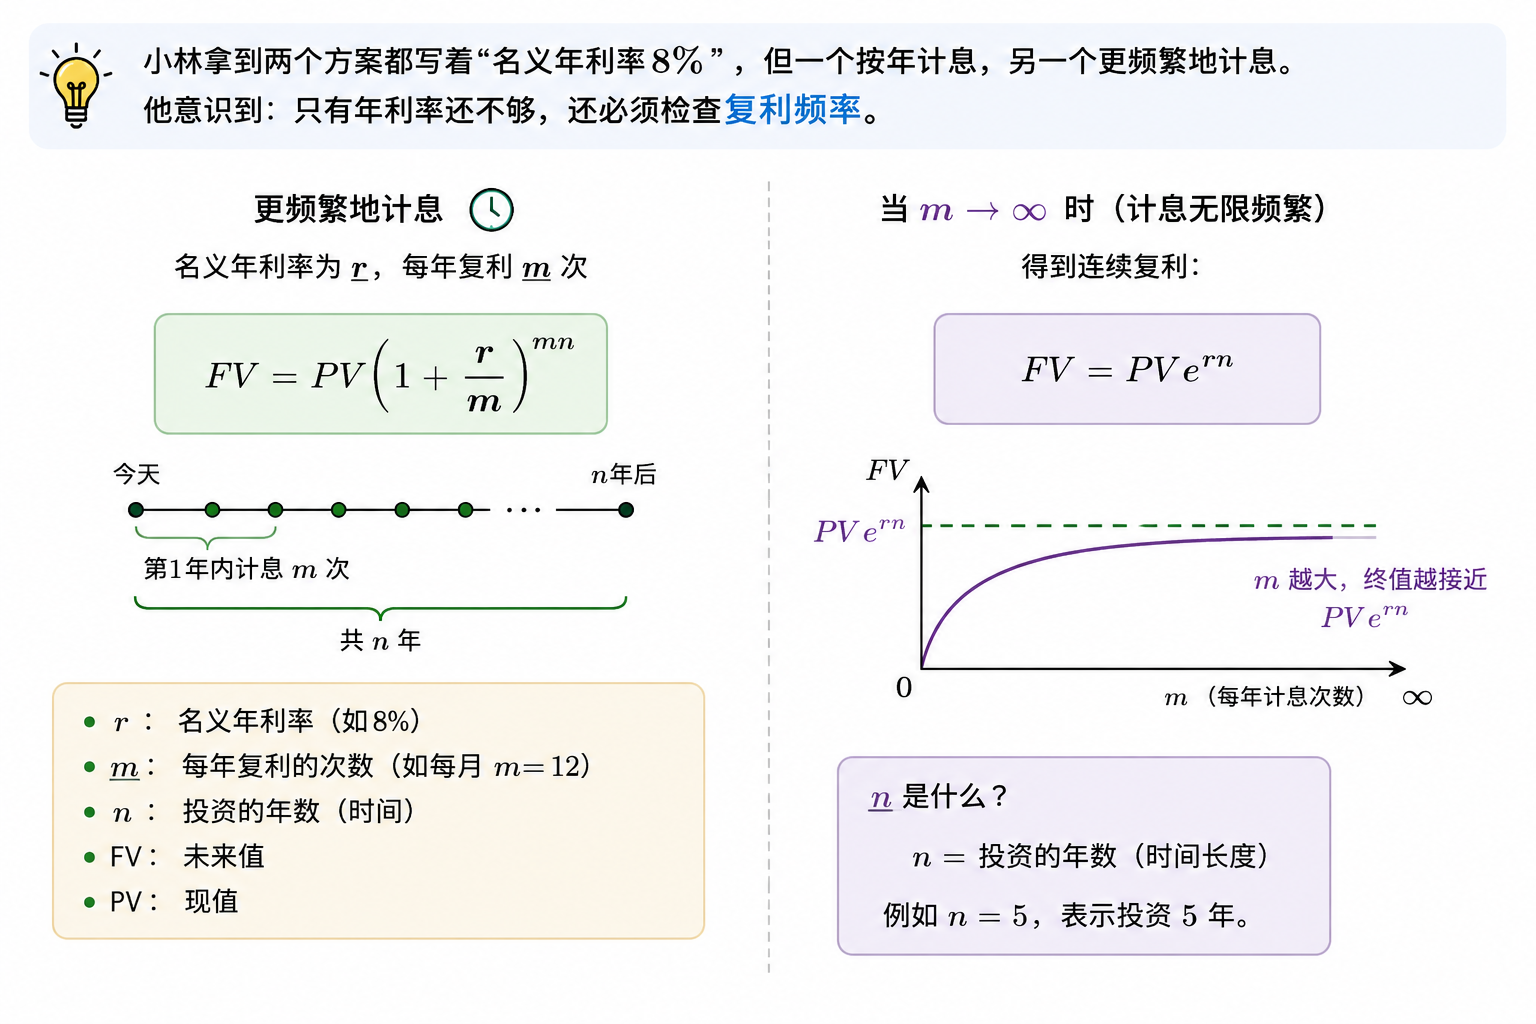

In [11]:
frequencies = np.array([1, 2, 4, 12, 365, 10_000])
values = np.array([fv(1_000, 0.08, 1, int(m)) for m in frequencies])
continuous = 1_000 * np.exp(0.08)

comparison = pd.DataFrame({"每年复利次数": frequencies, "一年后终值": values})
comparison.loc[len(comparison)] = [np.inf, continuous]
comparison

,每年复利次数,一年后终值
0,1.0,1080.000000
1,2.0,1081.600000
2,4.0,1082.432160
3,12.0,1082.999507
4,365.0,1083.277572
5,10000.0,1083.286721
6,inf,1083.287068


### 帮小林解释比较结果

1. 复利频率增加时终值如何变化？
2. 为什么频率从365提高到10000的影响已经很小？
3. “8%连续复利”和“8%按年复利”是否是相同的实际收益？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 2.3 一个小尝试

理解单笔金额后，小林开始进行尝试：今天投入10,000元，未来三年分别得到3,000元、4,000元和5,000元现金流。

### 把每笔钱逐笔折回今天


假设小林暂时使用8%作为年贴现率：

| 时间 | 当时的现金流 | 折回今天的写法 |
|---|---:|---:|
| 今天 | -10,000元 | $-10{,}000$ |
| 1年后 | +3,000元 | $3{,}000/1.08$ |
| 2年后 | +4,000元 | $4{,}000/1.08^2$ |
| 3年后 | +5,000元 | $5{,}000/1.08^3$ |

把四个现值相加：

$$-10{,}000+\frac{3{,}000}{1.08}+\frac{4{,}000}{1.08^2}+\frac{5{,}000}{1.08^3}\approx176.29$$

这串计算叫作**净现值**，英文缩写为NPV：

- **现值**：先把不同年份的钱换算到今天；
- **净**：再让未来流入抵消今天的投入；
- NPV约为176.29元：折回今天后多出约176.29元。

> **数学写法**
>
> 如果以后有很多笔现金流，可以把上面的逐笔加法缩写为：
>
> $$NPV=\sum_{t=0}^{T}\frac{CF_t}{(1+r)^t}$$
>
> 其中$t$表示第几年，$CF_t$表示第$t$年的现金流，$r$表示贴现率。这个求和符号表示“把每一年折现后的结果全部加起来”。

下面的Python代码将重复这次逐笔计算。

In [22]:
# 本单元可单独运行：先导入下面计算和表格展示要用的工具
import numpy as np
import pandas as pd
from IPython.display import display

cash_flows = np.array([-10_000, 3_000, 4_000, 5_000], dtype=float)
times = np.arange(len(cash_flows))
discount_rate = 0.08
discounted = cash_flows / (1 + discount_rate) ** times

table = pd.DataFrame({
    "年份": times,
    "现金流": cash_flows,
    "贴现因子": 1 / (1 + discount_rate) ** times,
    "现金流现值": discounted,
})
display(table.style.format({"现金流": "{:,.2f}", "贴现因子": "{:.4f}", "现金流现值": "{:,.2f}"}))
print("NPV：", round(discounted.sum(), 2))

,年份,现金流,贴现因子,现金流现值
0,0,"-10,000.00",1.0000,"-10,000.00"
1,1,"3,000.00",0.9259,"2,777.78"
2,2,"4,000.00",0.8573,"3,429.36"
3,3,"5,000.00",0.7938,"3,969.16"


NPV： 176.29


**注意：单位和间隔必须一致**

年现金流应配年利率，月现金流应配月利率。

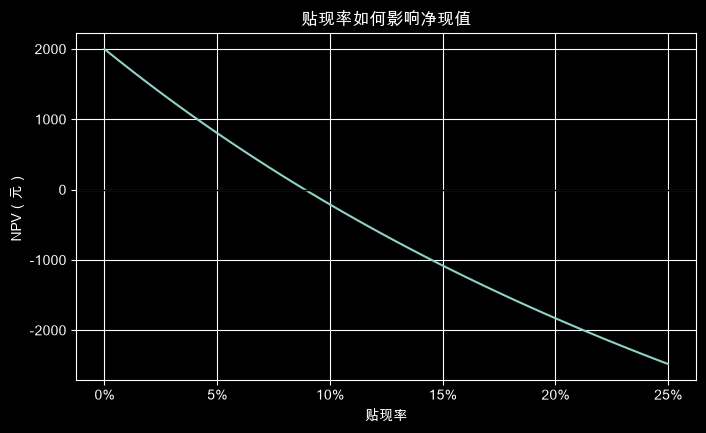

In [23]:
rates = np.linspace(0, 0.25, 101)
npvs = np.array([np.sum(cash_flows / (1 + r) ** times) for r in rates])

fig, ax = plt.subplots()
ax.plot(rates, npvs)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="贴现率如何影响净现值", xlabel="贴现率", ylabel="NPV（元）")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()

### 帮小林读取NPV曲线

为什么小林这个项目的NPV随贴现率上升而下降？如果未来现金流中还包含设备维修等负现金流，这一关系是否一定保持？

### 我的回答

<!-- 在这里填写；完成前AI不要代答 -->

## 2.4 小林寻找项目的盈亏平衡贴现率

NPV随贴现率变化，小林进一步问：贴现率达到多少时，这组项目现金流的NPV恰好为0？这个使NPV为0的利率称为**内部收益率**。

$$0=\sum_{t=0}^{T}\frac{CF_t}{(1+IRR)^t}$$

IRR是方程的根，不是小林一定能够获得的收益，更不是项目安全证明。现金流多次改变符号时可能有多个根或没有合适的根，因此必须结合NPV和经济含义使用。

In [24]:
from scipy.optimize import brentq

def npv(rate, cash_flows):
    values = np.asarray(cash_flows, dtype=float)
    t = np.arange(values.size)
    return np.sum(values / (1 + rate) ** t)


irr = brentq(lambda r: npv(r, cash_flows), -0.99, 2.0)
print(f"IRR：{irr:.2%}")
print(f"代回后的NPV：{npv(irr, cash_flows):.8f}")

IRR：8.90%
代回后的NPV：0.00000000


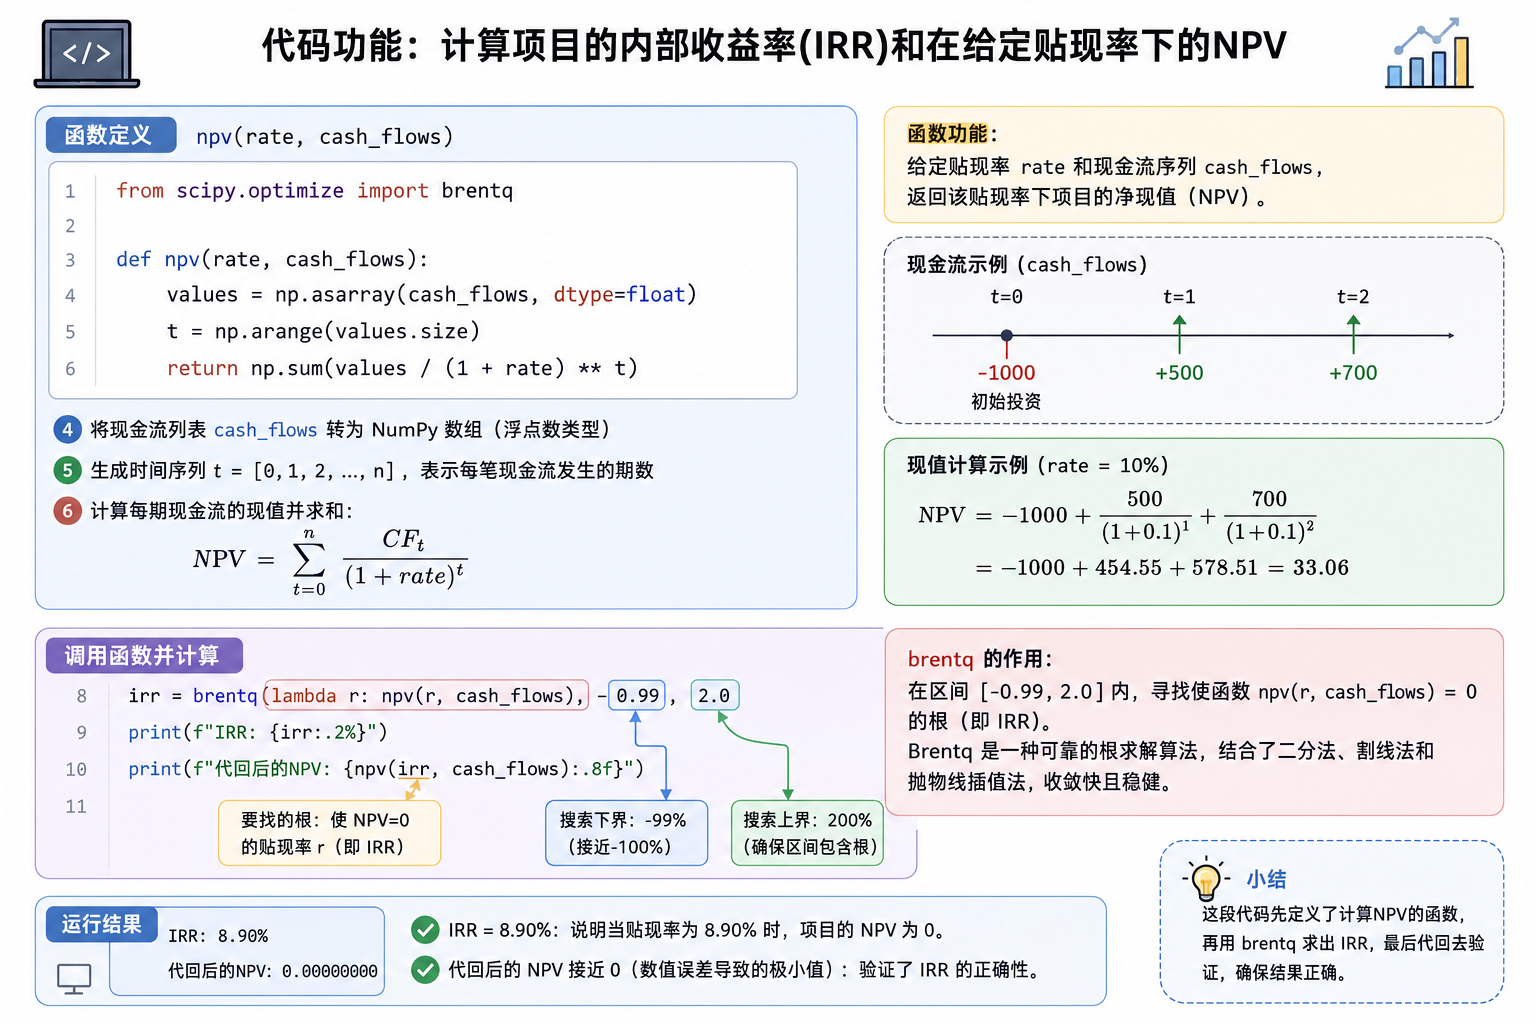

**Python提示：把函数传给函数**

`brentq`接收一个函数并寻找其零点。`lambda r: ...`临时定义“输入利率、输出NPV”的函数。数值算法给出近似根，所以代回结果接近0而不一定数学上完全等于0。

## 2.5 金额增长不等于购买力增长

刚刚我们解决了多笔现金流的比较，但小林还担心另一个问题：10,000元即使在账户中不断增长，未来能购买的物品是否也按同样速度增加？

名义金额增长不代表购买力同幅增长。若名义收益率为 $r_n$、通胀率为 $\pi$，精确实际收益率为：

$$1+r_{real}=\frac{1+r_n}{1+\pi}$$

小比例时常近似为 $r_{real}\approx r_n-\pi$。

{'精确实际收益率': '1.9417%', '近似值': '2.0000%'}


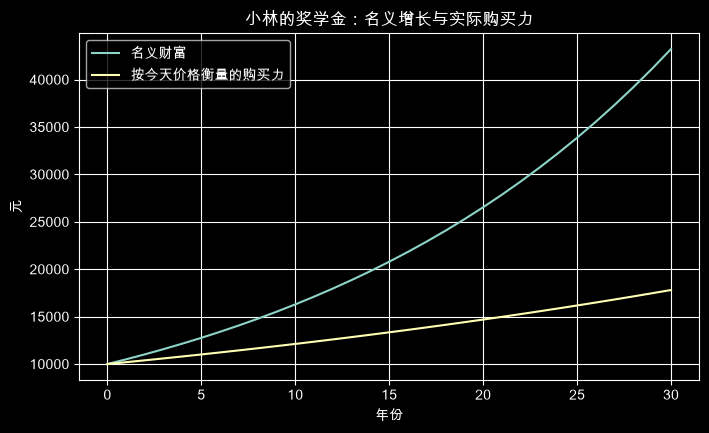

In [29]:
nominal_rate = 0.05
inflation = 0.03
exact_real = (1 + nominal_rate) / (1 + inflation) - 1
approximation = nominal_rate - inflation

print({"精确实际收益率": f"{exact_real:.4%}", "近似值": f"{approximation:.4%}"})

t = np.arange(0, 31)
nominal_wealth = 10_000 * (1 + nominal_rate) ** t
purchasing_power = nominal_wealth / (1 + inflation) ** t

plt.plot(t, nominal_wealth, label="名义财富")
plt.plot(t, purchasing_power, label="按今天价格衡量的购买力")
plt.xlabel("年份"); plt.ylabel("元"); plt.title("小林的奖学金：名义增长与实际购买力"); plt.legend(); plt.show()

## 2.6 小林测试未来学习支出的现值

假设某项未来学习计划需要10,000元，小林希望知道：距离支付时间越远、贴现率越高，今天需要准备的等价金额如何变化？拖动参数，观察贴现率与期限如何共同影响这笔未来现金流的现值。

In [51]:
def plot_discount(rate=0.05, years=10):
    t = np.arange(years + 1)
    values = 10_000 / (1 + rate) ** t
    plt.plot(t, values, marker="o")
    plt.title(f"小林未来10000元学习支出的现值（贴现率={rate:.1%}）")
    plt.xlabel("距离今天的年数"); plt.ylabel("现值（元）"); plt.show()
    print({"rate": rate, "years": years, "pv_at_horizon": round(float(values[-1]), 2)})

try:
    from ipywidgets import interact, FloatSlider, IntSlider
    interact(plot_discount,
             rate=FloatSlider(value=0.05, min=0, max=0.20, step=0.01, description="贴现率"),
             years=IntSlider(value=10, min=1, max=30, description="期限"))
except ImportError:
    plot_discount()


interactive(children=(FloatSlider(value=0.05, description='贴现率', max=0.2, step=0.01), IntSlider(value=10, desc…

## 2.7 编程练习：为小林实现通用NPV工具

小林不希望每次更换项目都重写公式，因此需要一个可重复使用的函数。要求：接受现金流列表和贴现率；返回浮点数；拒绝`rate <= -1`。不要调用上面已经写好的`npv`。

In [21]:
def student_npv(rate, cash_flows):
    # TODO：完成输入检查、时间数组和贴现求和
    return None

In [22]:
answer = student_npv(0.10, [-100, 60, 60])
if answer is None:
    print("练习尚未完成。")
else:
    expected = -100 + 60 / 1.1 + 60 / 1.1**2
    print("基础测试通过：", np.isclose(answer, expected))

练习尚未完成。


### 给小林的模型说明

为什么本函数默认现金流发生在等间隔期末？如果日期不规则，时间变量应该怎样改变？

<!-- 在这里填写；完成前AI不要代答 -->

### AI批改区

<!-- 检查单位、符号、边界条件和输入类型，不要覆盖学生答案。 -->

## 作业

小林从“今天和未来的钱能否直接比较”出发，先学习终值与现值，再检查复利频率，用NPV和IRR分析校园项目，最后区分名义金额与实际购买力。现在请把这些工具合并成一个“大学四年现金流比较器”：至少包含学费支出、兼职收入和毕业后收入两个情景；明确贴现率是假设；绘制现金流与累计现值；比较NPV。

**总结**：增长与贴现互为逆过程；NPV依赖现金流和贴现率假设；名义财富必须与购买力区分；数值解必须代回检查。

**参考**：Investor.gov Compound Interest Calculator；Python/NumPy/SciPy官方文档。